<a href="https://colab.research.google.com/github/soham-never-codes/Festiva-AI-Event-Planner/blob/main/notebooks/Festiva_Week1_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive (always first)

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/festiva'

os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/rag', exist_ok=True)

print(" Drive mounted. Project folder architecture ready.")

Mounted at /content/drive
 Drive mounted. Project folder architecture ready.


In [ ]:
# Install libraries

!pip install -q pandas numpy scikit-learn matplotlib seaborn
print(" Libraries installed.")

 Libraries installed.


In [ ]:
#  Generate synthetic dataset

import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

EVENT_TYPES = ["wedding", "corporate", "birthday", "engagement", "conference"]
CITIES = ["Bangalore", "Mumbai", "Delhi", "Chennai", "Hyderabad", "Pune"]
SEASONS = ["winter", "summer", "monsoon"]

BUDGET_PROFILES = {
    "wedding":     {"venue":(0.25,0.35),"catering":(0.20,0.30),"decoration":(0.10,0.18),
                    "photography":(0.08,0.12),"entertainment":(0.05,0.10),
                    "invitations":(0.02,0.05),"miscellaneous":(0.05,0.10)},
    "corporate":   {"venue":(0.30,0.40),"catering":(0.20,0.28),"av_equipment":(0.10,0.18),
                    "decoration":(0.05,0.10),"speakers":(0.05,0.12),
                    "invitations":(0.02,0.04),"miscellaneous":(0.05,0.10)},
    "birthday":    {"venue":(0.20,0.30),"catering":(0.25,0.35),"cake":(0.05,0.10),
                    "decoration":(0.10,0.18),"entertainment":(0.08,0.15),
                    "invitations":(0.02,0.05),"miscellaneous":(0.05,0.10)},
    "engagement":  {"venue":(0.22,0.32),"catering":(0.20,0.28),"decoration":(0.12,0.20),
                    "photography":(0.10,0.15),"jewelry_display":(0.05,0.10),
                    "invitations":(0.03,0.06),"miscellaneous":(0.05,0.10)},
    "conference":  {"venue":(0.35,0.45),"catering":(0.15,0.22),"av_equipment":(0.12,0.20),
                    "marketing":(0.08,0.14),"speakers":(0.05,0.10),
                    "invitations":(0.02,0.04),"miscellaneous":(0.03,0.08)},
}

CITY_MULT = {"Mumbai":1.4,"Delhi":1.3,"Bangalore":1.2,"Pune":1.1,"Chennai":1.1,"Hyderabad":1.0}

records = []
for _ in range(2000):
    etype = random.choice(EVENT_TYPES)
    city  = random.choice(CITIES)

    # [FIXED] Base budget is now mathematically tied to guest count
    guests = random.randint(50, 800)
    cost_per_head = random.randint(1500, 8000)
    base = guests * cost_per_head

    budget = int(base * CITY_MULT[city] * random.uniform(0.9, 1.1))

    profile = BUDGET_PROFILES[etype]
    alloc = {k: random.uniform(lo, hi) for k, (lo, hi) in profile.items()}
    total_pct = sum(alloc.values())
    alloc = {k: v/total_pct for k, v in alloc.items()}
    amounts = {k: int(v * budget) for k, v in alloc.items()}

    records.append({
        "event_type": etype, "city": city, "guest_count": guests,
        "total_budget": budget, "duration_days": random.randint(1, 3),
        "season": random.choice(SEASONS), **amounts
    })

df = pd.DataFrame(records).fillna(0)
df.to_csv(f'{PROJECT_DIR}/data/raw/event_budget_data.csv', index=False)
print(f"✅ Saved {len(df)} rows to {PROJECT_DIR}/data/raw/event_budget_data.csv")
display(df.head())

✅ Saved 2000 rows to /content/drive/MyDrive/festiva/data/raw/event_budget_data.csv


,event_type,city,guest_count,total_budget,duration_days,season,venue,catering,decoration,photography,entertainment,invitations,miscellaneous,av_equipment,speakers,marketing,cake,jewelry_display
0,wedding,Bangalore,331,1315492,3,monsoon,426142,352438,225646.0,109913.0,93611.0,27510,80228,0.0,0.0,0.0,0.0,0.0
1,wedding,Hyderabad,253,1919202,2,summer,605290,441391,292495.0,223389.0,100038.0,87812,168782,0.0,0.0,0.0,0.0,0.0
2,corporate,Mumbai,394,1184091,2,winter,350357,302983,102227.0,0.0,0.0,34761,111617,167781.0,114361.0,0.0,0.0,0.0
3,conference,Delhi,693,6371322,1,summer,2470283,1045653,0.0,0.0,0.0,253988,465482,803234.0,567114.0,765564.0,0.0,0.0
4,birthday,Chennai,700,3222602,1,winter,764303,1028746,501960.0,0.0,275825.0,126718,248920,0.0,0.0,0.0,276126.0,0.0


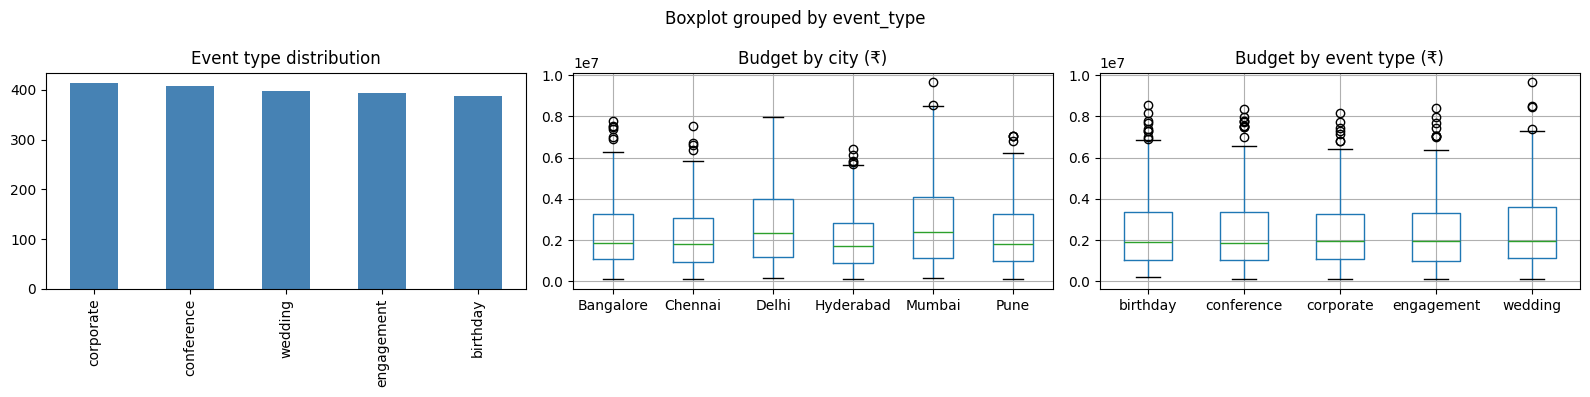

✅ EDA saved to Drive


In [ ]:
#   EDA — distributions

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Event type distribution
df['event_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Event type distribution')
axes[0].set_xlabel('')

# Budget distribution by city
df.boxplot(column='total_budget', by='city', ax=axes[1])
axes[1].set_title('Budget by city (₹)')
axes[1].set_xlabel('')

# Budget distribution by event type
df.boxplot(column='total_budget', by='event_type', ax=axes[2])
axes[2].set_title('Budget by event type (₹)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/data/eda_plots.png', dpi=120)
plt.show()
print("✅ EDA saved to Drive")

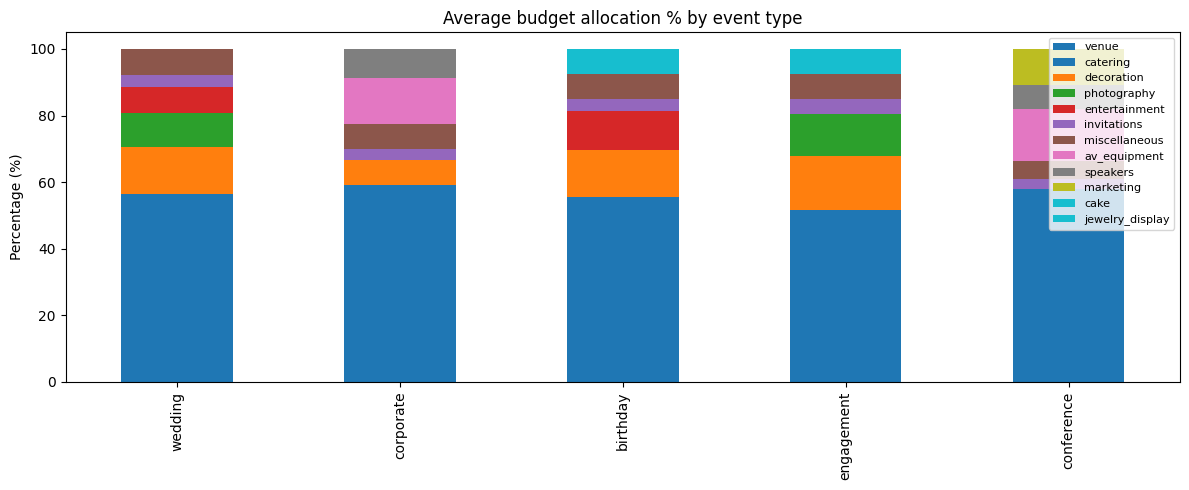

✅ Budget allocation plots saved to Drive


In [ ]:
#  Category spend analysis

spend_cols = [c for c in df.columns if c not in
              ['event_type','city','guest_count','total_budget','duration_days','season']]

avg_pct = {}
for etype in EVENT_TYPES:
    sub = df[df.event_type == etype]
    pcts = {}
    for col in spend_cols:
        if col in sub.columns:
            pcts[col] = (sub[col] / sub['total_budget']).mean() * 100
    avg_pct[etype] = pcts

pct_df = pd.DataFrame(avg_pct).T.fillna(0)
pct_df.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')

plt.title('Average budget allocation % by event type')
plt.ylabel('Percentage (%)')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.savefig(f'{PROJECT_DIR}/data/budget_allocation.png', dpi=120)
plt.show()
print("✅ Budget allocation plots saved to Drive")